<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Collecting Job Data Using APIs**


Estimated time needed: **30** minutes


## Objectives


After completing this lab, you will be able to:


*   Collect job data using Jobs API
*   Store the collected data into an excel spreadsheet.


><strong>Note: Before starting with the assignment make sure to read all the instructions and then move ahead with the coding part.</strong>


#### Instructions


To run the actual lab, firstly you need to click on the [Jobs_API](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/Jobs_API.ipynb) notebook link. The file contains flask code which is required to run the Jobs API data.

Now, to run the code in the file that opens up follow the below steps.

Step1: Download the file. 

Step2: Upload the file into your current Jupyter environment using the upload button in your Jupyter interface. Ensure that the file is in the same folder as your working .ipynb file.

Step 2: If working in a local Jupyter environment, use the "Upload" button in your Jupyter interface to upload the Jobs_API notebook into the same folder as your current .ipynb file.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/Upload.PNG">

Step3:  Open the Jobs_API notebook, and run all the cells to start the Flask application. Once the server is running, you can access the API from the URL provided in the notebook.

If you want to learn more about flask, which is optional, you can click on this link [here](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/FLASK_API.md.html).

Once you run the flask code, you can start with your assignment.


## Dataset Used in this Assignment

The dataset used in this lab comes from the following source: https://www.kaggle.com/promptcloud/jobs-on-naukricom under the under a **Public Domain license**.

> Note: We are using a modified subset of that dataset for the lab, so to follow the lab instructions successfully please use the dataset provided with the lab, rather than the dataset from the original source.

The original dataset is a csv. We have converted the csv to json as per the requirement of the lab.


## Warm-Up Exercise


Before you attempt the actual lab, here is a fully solved warmup exercise that will help you to learn how to access an API.


Using an API, let us find out who currently are on the International Space Station (ISS).<br> The API at [http://api.open-notify.org/astros.json](http://api.open-notify.org/astros.json?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork21426264-2021-01-01&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ) gives us the information of astronauts currently on ISS in json format.<br>
You can read more about this API at [http://open-notify.org/Open-Notify-API/People-In-Space/](http://open-notify.org/Open-Notify-API/People-In-Space?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork21426264-2021-01-01&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)


In [1]:
import requests # you need this module to make an API call
import pandas as pd

In [2]:
api_url = "http://api.open-notify.org/astros.json" # this url gives use the astronaut data

In [3]:
response = requests.get(api_url) # Call the API using the get method and store the
                                # output of the API call in a variable called response.

In [4]:
if response.ok:             # if all is well() no errors, no network timeouts)
    data = response.json()  # store the result in json format in a variable called data
                            # the variable data is of type dictionary.

In [5]:
print(data)   # print the data just to check the output or for debugging

{'people': [{'craft': 'ISS', 'name': 'Oleg Kononenko'}, {'craft': 'ISS', 'name': 'Nikolai Chub'}, {'craft': 'ISS', 'name': 'Tracy Caldwell Dyson'}, {'craft': 'ISS', 'name': 'Matthew Dominick'}, {'craft': 'ISS', 'name': 'Michael Barratt'}, {'craft': 'ISS', 'name': 'Jeanette Epps'}, {'craft': 'ISS', 'name': 'Alexander Grebenkin'}, {'craft': 'ISS', 'name': 'Butch Wilmore'}, {'craft': 'ISS', 'name': 'Sunita Williams'}, {'craft': 'Tiangong', 'name': 'Li Guangsu'}, {'craft': 'Tiangong', 'name': 'Li Cong'}, {'craft': 'Tiangong', 'name': 'Ye Guangfu'}], 'number': 12, 'message': 'success'}


Print the number of astronauts currently on ISS.


In [6]:
print(data.get('number'))

12


Print the names of the astronauts currently on ISS.


In [7]:
astronauts = data.get('people')
print("There are {} astronauts on ISS".format(len(astronauts)))
print("And their names are :")
for astronaut in astronauts:
    print(astronaut.get('name'))

There are 12 astronauts on ISS
And their names are :
Oleg Kononenko
Nikolai Chub
Tracy Caldwell Dyson
Matthew Dominick
Michael Barratt
Jeanette Epps
Alexander Grebenkin
Butch Wilmore
Sunita Williams
Li Guangsu
Li Cong
Ye Guangfu


Hope the warmup was helpful. Good luck with your next lab!


## Lab: Collect Jobs Data using Jobs API


### Objective: Determine the number of jobs currently open for various technologies  and for various locations


Collect the number of job postings for the following locations using the API:

* Los Angeles
* New York
* San Francisco
* Washington DC
* Seattle
* Austin
* Detroit


In [8]:
#Import required libraries
import pandas as pd
import json


#### Write a function to get the number of jobs for the Python technology.
> **Note:** 
While completing this exercise, first retrieve the full dataset from the API endpoint.  
After retrieving the data, apply the required filtering and calculations locally in Python based on the given parameters.
  
 ##### The keys in the json are 
 * Job Title
 
 * Job Experience Required
 
 * Key Skills
 
 * Role Category
 
 * Location
 
 * Functional Area
 
 * Industry
 
 * Role 
 
You can also view  the json file contents  from the following URL.

https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json



In [50]:
api_url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"

def get_number_of_jobs_T(technology):
# Step 1: Fetch data from the web
    response = requests.get(api_url)
    data = response.json()
    
    # Step 2: Initialize the counter (THIS FIXES THE NAMEERROR)
    # We create the variable here so it exists when we try to return it later.
    number_of_jobs_T = 0
    
    # Step 3: Iterate through the data to count matching technologies
    for job in data:
        # Extract the 'Key Skills' text; use an empty string if the field is missing
        skills = job.get('Key Skills', '')
        
        # Check if the requested technology is present (case-insensitive)
        if technology.lower() in skills.lower():
            number_of_jobs_T += 1
            
    return technology, number_of_jobs_T

Calling the function for Python and checking if it works.


In [35]:
print(get_number_of_jobs_T("Python"))

('Python', 1173)


#### Write a function to find number of jobs in US for a location of your choice and Call the function for Los Angeles and check it is working.


In [21]:
import requests

# API endpoint URL
api_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"

def get_number_of_jobs_L(location):
    # Step 1: Fetch all data from the web API
    response = requests.get(api_url)
    # Parse the JSON response into a Python list of dictionaries
    data = response.json() 
    
    # Step 2: Initialize the counter variable to zero
    number_of_jobs = 0
    
    # Step 3: Iterate through each job record and check if the location matches
    for job in data:
        # Check if the 'Location' key in the job dictionary matches the input argument
        if job.get('Location') == location:
            number_of_jobs += 1 # Increment the count if a match is found
            
    return location, number_of_jobs

# Verification: Execute the function for "Los Angeles"
print(get_number_of_jobs_L("Los Angeles"))

('Los Angeles', 640)


### Store the results in an excel file


Call the API for all the given locations above and write the results in an excel spreadsheet


If you do not know how create excel file using python, double click here for **hints**.

<!--

from openpyxl import Workbook        # import Workbook class from module openpyxl
wb=Workbook()                        # create a workbook object
ws=wb.active                         # use the active worksheet
ws.append(['Country','Continent'])   # add a row with two columns 'Country' and 'Continent'
ws.append(['Eygpt','Africa'])        # add a row with two columns 'Egypt' and 'Africa'
ws.append(['India','Asia'])          # add another row
ws.append(['France','Europe'])       # add another row
wb.save("countries.xlsx")            # save the workbook into a file called countries.xlsx


-->


Create a python list of all locations for which you need to find the number of jobs postings.


In [49]:
import requests
from openpyxl import Workbook

# API endpoint URL
api_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"

# Step 1: Create a list of all locations to investigate
locations = ["Los Angeles", "New York", "San Francisco", "Washington DC", "Seattle", "Austin", "Detroit"]

def export_job_data_to_excel(url, location_list):
    # Step 2: Fetch all data from the API (One single request for efficiency)
    response = requests.get(url)
    data = response.json()
    
    # Step 3: Initialize the Excel Workbook
    wb = Workbook()
    ws = wb.active
    ws.title = "Job Postings"
    
    # Add column headers
    ws.append(['Location', 'Number of Jobs'])
    
    # Step 4: Aggregate counts for each location and write to the sheet
    for loc in location_list:
        # Count the number of jobs where 'Location' matches the current item in the list
        number_of_jobs = sum(1 for job in data if job.get('Location') == loc)
        
        # Append the result as a new row in the Excel sheet
        ws.append([loc, number_of_jobs])
        
    # Step 5: Save the workbook to the local file system
    file_name = "job-postings.xlsx"
    wb.save(file_name)
    
    print(f"Data successfully exported to {file_name}")

# Execute the function
export_job_data_to_excel(api_url, locations)

Data successfully exported to job-postings.xlsx


Import libraries required to create excel spreadsheet


In [43]:
# your code goes here
import pandas as pd

Create a workbook and select the active worksheet


In [44]:
%pip install openpyxl
from openpyxl import Workbook


# 1. Create a new Workbook object (this represents the entire Excel file)
wb = Workbook()

# 2. Select the currently active worksheet (the first sheet created by default)
ws = wb.active

# 3. (Optional but recommended) Give the sheet a meaningful name
ws.title = "Job_Market_Data"

Note: you may need to restart the kernel to use updated packages.


Find the number of jobs postings for each of the location in the above list.
Write the location name and the number of jobs postings into the excel spreadsheet.


In [45]:
import requests
import pandas as pd

# 1. Define the API endpoint and the list of cities to investigate
api_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"
locations = ["Los Angeles", "New York", "San Francisco", "Washington DC", "Seattle", "Austin", "Detroit"]

def export_job_data_to_excel(url, location_list):
    # Step 1: Fetch raw data from the web API
    response = requests.get(url)
    data = response.json()
    
    # Step 2: Iterate through the city list and count job postings for each
    results = []
    for loc in location_list:
        # Using list comprehension to sum up matches for the given location
        number_of_jobs = sum(1 for job in data if job.get('Location') == loc)
        
        # Append the city name and count as a dictionary to our results list
        results.append({"Location": loc, "Number of Jobs": number_of_jobs})
    
    # Step 3: Convert the collected data into a structured "DataFrame" (table)
    df = pd.DataFrame(results)
    
    # Step 4: Export the DataFrame to an Excel file
    # Note: Ensure the 'openpyxl' library is installed for Excel support
    file_name = "job_postings_report.xlsx"
    df.to_excel(file_name, index=False)
    
    print(f"Aggregation complete. Report saved as: {file_name}")
    return df

# Execute the function
df_result = export_job_data_to_excel(api_url, locations)

# Display the resulting table in the console for verification
print(df_result)

Aggregation complete. Report saved as: job_postings_report.xlsx
        Location  Number of Jobs
0    Los Angeles             640
1       New York            3226
2  San Francisco             435
3  Washington DC            5316
4        Seattle            3375
5         Austin             434
6        Detroit            3945


Save into an excel spreadsheet named **job-postings.xlsx**.


In [46]:
#your code goes here
import requests
import pandas as pd

# 1. Configuration: API URL and the list of cities
api_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"
locations = ["Los Angeles", "New York", "San Francisco", "Washington DC", "Seattle", "Austin", "Detroit"]

def export_job_data_to_excel(url, location_list, output_filename):
    # Step 1: Fetch raw data from the API
    response = requests.get(url)
    data = response.json()
    
    # Step 2: Loop through each city and count the matching job postings
    results = []
    for loc in location_list:
        # We use sum(1...) for a memory-efficient count of matches
        count = sum(1 for job in data if job.get('Location') == loc)
        results.append({"Location": loc, "Number of Jobs": count})
    
    # Step 3: Structure the aggregated data into a Table (DataFrame)
    df = pd.DataFrame(results)
    
    # Step 4: Export the table to the Excel file
    # Ensure you have 'openpyxl' installed (%pip install openpyxl)
    df.to_excel(output_filename, index=False)
    
    print(f"Success! Data has been aggregated and saved to: {output_filename}")
    return df

# Execute the function with your requested filename
df_final = export_job_data_to_excel(api_url, locations, "job-postings.xlsx")

# Display the results in the notebook for a quick check
print(df_final)

Success! Data has been aggregated and saved to: job-postings.xlsx
        Location  Number of Jobs
0    Los Angeles             640
1       New York            3226
2  San Francisco             435
3  Washington DC            5316
4        Seattle            3375
5         Austin             434
6        Detroit            3945


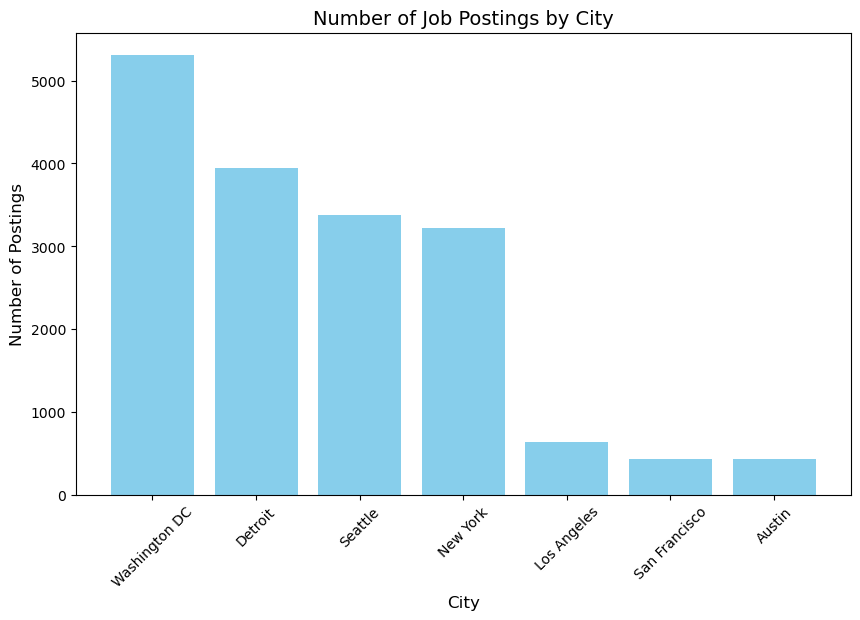

In [48]:
#Present that data using a bar chart here. Order the bar chart in the descending order of the number of job postings.

import requests
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuration
api_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"
locations = ["Los Angeles", "New York", "San Francisco", "Washington DC", "Seattle", "Austin", "Detroit"]

def create_job_bar_chart(url, location_list):
    # Step 1: Fetch raw data
    response = requests.get(url)
    data = response.json()
    
    # Step 2: Aggregate counts into a list of dictionaries
    results = []
    for loc in location_list:
        count = sum(1 for job in data if job.get('Location') == loc)
        results.append({"Location": loc, "Number of Jobs": count})
    
    # Step 3: Create a DataFrame and sort by "Number of Jobs" in DESCENDING order
    df = pd.DataFrame(results)
    df_sorted = df.sort_values(by="Number of Jobs", ascending=False)
    
    # Step 4: Generate the Bar Chart
    plt.figure(figsize=(10, 6))
    plt.bar(df_sorted["Location"], df_sorted["Number of Jobs"], color='skyblue')
    
    # Add styling and labels
    plt.title("Number of Job Postings by City", fontsize=14)
    plt.xlabel("City", fontsize=12)
    plt.ylabel("Number of Postings", fontsize=12)
    plt.xticks(rotation=45) # Rotate city names for better readability
    
    # Save the chart as an image
    plt.savefig("job_postings_chart.png", bbox_inches='tight')
    
    # Show the plot in the notebook
    plt.show()
    
    return df_sorted

# Execute the function
df_result = create_job_bar_chart(api_url, locations)

## Authors


Ayushi Jain


### Other Contributors


Rav Ahuja

Lakshmi Holla

Malika


Copyright © IBM Corporation.


<!--## Change Log


<!--| Date (YYYY-MM-DD) | Version | Changed By        | Change Description                 |
| ----------------- | ------- | ----------------- | ---------------------------------- | 
| 2022-01-19        | 0.3     | Lakshmi Holla        | Added changes in the markdown      |
| 2021-06-25        | 0.2     | Malika            | Updated GitHub job json link       |
| 2020-10-17        | 0.1     | Ramesh Sannareddy | Created initial version of the lab |--!>
